## Librerias 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import numpy as np
from lib.LCWavelet import *
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import optuna
import pandas as pd

## Arquitectura del modelo

In [2]:
class SkipLayer(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=(1,5),
                 stride=1,
                 padding=(0,2),
                 conv_size=2,
                 pool_kernel=(1,5),
                 pool_stride=(1,2)):
        """
        - in_channels/out_channels: canales antes y después de la rama conv.
        - kernel_size, stride, padding: parámetros de cada Conv2d.
        - conv_size: cuántas conv+BN+ReLU encadenas antes del pool.
        - pool_kernel/stride: parámetros del MaxPool2d.
        """
        super().__init__()
        # 1) Rama convolucional
        layers = []
        c_in = in_channels
        for i in range(conv_size):
            layers += [
                nn.Conv2d(c_in, out_channels,
                          kernel_size=kernel_size if i==0 else (1, kernel_size[1]),
                          stride=stride,
                          padding=padding if i==0 else (0, padding[1])),
                # nn.BatchNorm2d(out_channels, track_running_stats=False),
                nn.ReLU()
            ]
            c_in = out_channels

        layers += [
            nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)
        ]
        self.conv_branch = nn.Sequential(*layers)

        # 2) Rama identidad: same pool + conv1x1 para ajustar canales
        self.id_branch = nn.Sequential(
            nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride),
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            # nn.BatchNorm2d(out_channels, track_running_stats=False),
        )

    def forward(self, x):
        out = self.conv_branch(x)   # → [B, out_channels, H_out, W_out]
        idt = self.id_branch(x)     # → [B, out_channels, H_out, W_out]
        return F.relu(out + idt)

    
class ShallueModel2DSkip(nn.Module):
    def __init__(self, global_size=2001, local_size=201,
                 num_classes=2, wavelet_levels=[]):
        super().__init__()
        c_in = len(wavelet_levels)*2 if wavelet_levels else 2
        self.num_classes = num_classes
        if num_classes == 1:
            print("Binary classification → sigmoid output")
        else:
            print("Multi-class classification → softmax output")
        print(f"Wavelet levels: {wavelet_levels}")
        print(f"c_in: {c_in}")
        # Branch global
        self.conv_global = nn.Sequential(
            # kernel_height=c_in para abarcar las filas, kernel_width=5
            SkipLayer(1,  16,
                      kernel_size=(c_in, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(16,   32, 
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(32,   64,
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(64,  128,
                        kernel_size=(1, 5),
                        padding=(0,2),
                        conv_size=2,
                        pool_kernel=(1,5),
                        pool_stride=(1,2)),
            SkipLayer(128, 256,
                        kernel_size=(1, 5),
                        padding=(0,2),
                        conv_size=2,
                        pool_kernel=(1,5),
                        pool_stride=(1,2))
        )

        # Branch local (idéntico pero con local_size)
        self.conv_local = nn.Sequential(
            SkipLayer(1,  16,
                      kernel_size=(c_in, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,7),
                      pool_stride=(1,2)),
            SkipLayer(16,   32,
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,7),
                      pool_stride=(1,2)),
        )

        # Calcular num_features como antes
        for m in self.modules():
            # desactiva gradientes en todas las capas
            for p in m.parameters():
                p.requires_grad_(False)
                
        with torch.no_grad():
            dg = torch.zeros(1, 1, c_in, global_size)
            dl = torch.zeros(1, 1, c_in, local_size)
            og = self.conv_global(dg)
            ol = self.conv_local(dl)
            num_features = og.view(1, -1).size(1) + ol.view(1, -1).size(1)
            
        # ahora reactiva los gradientes
        for m in self.modules():
            for p in m.parameters():
                p.requires_grad_(True)
            
        print(f"Número de features concatenados: {num_features}")
        self.fc = nn.Sequential(
            nn.Linear(num_features, 512), nn.ReLU(),
            nn.Linear(512, 256),          nn.ReLU(),
            nn.Linear(256,  64),          nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, inputs):
        g, l = inputs  # cada uno [B, C_in, L]
        g = g.unsqueeze(1)  # → [B, 1, C_in, L]
        l = l.unsqueeze(1)
        g_feat = self.conv_global(g)
        l_feat = self.conv_local(l)
        # aplanar y concatenar
        g_feat = g_feat.view(g_feat.size(0), -1)
        l_feat = l_feat.view(l_feat.size(0), -1)
        x = torch.cat((g_feat, l_feat), dim=1)
        x = self.fc(x)
        if self.num_classes > 1:
            return F.softmax(x, dim=1)
        else:
            return torch.sigmoid(x)


class Shallue2DSkip2Channels(nn.Module):
    def __init__(self, global_size=2001, local_size=201,
                 num_classes=2, wavelet_levels=[]):
        super().__init__()
        c_in_global = len(wavelet_levels[0]) if wavelet_levels else 2
        c_in_local = len(wavelet_levels[1]) if wavelet_levels else 2
        self.num_classes = num_classes
        if num_classes == 1:
            print("Binary classification → sigmoid output")
        else:
            print("Multi-class classification → softmax output")
        print(f"Wavelet levels: {wavelet_levels}")
        print(f"c_in: {c_in_global} (global), {c_in_local} (local)")
        # Branch global
        self.conv_global = nn.Sequential(
            # kernel_height=c_in para abarcar las filas, kernel_width=5
            SkipLayer(2,  16,
                      kernel_size=(c_in_global, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(16,   32, 
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(32,   64,
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,5),
                      pool_stride=(1,2)),
            SkipLayer(64,  128,
                        kernel_size=(1, 5),
                        padding=(0,2),
                        conv_size=2,
                        pool_kernel=(1,5),
                        pool_stride=(1,2)),
            SkipLayer(128, 256,
                        kernel_size=(1, 5),
                        padding=(0,2),
                        conv_size=2,
                        pool_kernel=(1,5),
                        pool_stride=(1,2))
        )

        # Branch local (idéntico pero con local_size)
        self.conv_local = nn.Sequential(
            SkipLayer(2,  16,
                      kernel_size=(c_in_local, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,7),
                      pool_stride=(1,2)),
            SkipLayer(16,   32,
                      kernel_size=(1, 5),
                      padding=(0,2),
                      conv_size=2,
                      pool_kernel=(1,7),
                      pool_stride=(1,2)),
        )

        # Calcular num_features como antes
        for m in self.modules():
            # desactiva gradientes en todas las capas
            for p in m.parameters():
                p.requires_grad_(False)
                
        with torch.no_grad():
            dg = torch.zeros(1, 2, c_in_global, global_size)
            dl = torch.zeros(1, 2, c_in_local, local_size)
            og = self.conv_global(dg)
            ol = self.conv_local(dl)
            num_features = og.view(1, -1).size(1) + ol.view(1, -1).size(1)
            
        # ahora reactiva los gradientes
        for m in self.modules():
            for p in m.parameters():
                p.requires_grad_(True)
            
        print(f"Número de features concatenados: {num_features}")
        self.fc = nn.Sequential(
            nn.Linear(num_features, 512), nn.ReLU(),
            nn.Linear(512, 256),          nn.ReLU(),
            nn.Linear(256,  64),          nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, inputs):
        g, l = inputs  # cada uno [B, C_in, L]
        # g = g.unsqueeze(1)  # → [B, 1, C_in, L]
        # l = l.unsqueeze(1)
        
    # Reordenar a [B, 2, c_in, L]
        g = g.permute(0, 2, 1, 3)
        l = l.permute(0, 2, 1, 3)
        g_feat = self.conv_global(g)
        l_feat = self.conv_local(l)
        # aplanar y concatenar
        g_feat = g_feat.view(g_feat.size(0), -1)
        l_feat = l_feat.view(l_feat.size(0), -1)
        x = torch.cat((g_feat, l_feat), dim=1)
        x = self.fc(x)
        if self.num_classes > 1:
            return F.softmax(x, dim=1)
        else:
            return torch.sigmoid(x)

## Cargado de datos

In [16]:
def load_data(path, file_name):
    lc = LightCurveWaveletGlobalLocalCollection.from_pickle(path + file_name)
    try:
        getattr(lc, 'levels')
    except AttributeError:
        lc.levels = [1, 2, 3, 4]
    return lc
        
path='all_data_2025_B3/'
files = os.listdir(path)
kepler_files = [f for f in files if f.endswith('.pickle')]
light_curves = []

for file in tqdm(kepler_files, desc='Loading data'):
    light_curves.append(load_data(path, file))

Loading data: 100%|██████████| 9298/9298 [00:45<00:00, 203.95it/s]


### Separar entre los confirmados y candidatos

In [ ]:
dataset_2022 = pd.read_csv(r'csv/cumulative_2022.09.30_09.06.43.csv', skiprows=144)
dataset_2025 = pd.read_csv(r'csv/cumulative_2025.11.25_08.30.17.csv', skiprows=144)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200


In [39]:
# labeled the data with the 2022 dataset
labels_2022 = {}
for index, row in dataset_2022.iterrows():
    kepid = row['kepid']
    label = row['koi_disposition']
    labels_2022[kepid] = label

for lc in light_curves:
    kepid = lc.kepler_id
    if kepid in labels_2022:
        lc.headers['class_2022'] = labels_2022[kepid]


In [63]:
candidates = [lc for lc in light_curves if lc.headers['class_2022'] == 'CANDIDATE']
print("Número de candidatos:", len(candidates))

confirmed = [lc for lc in light_curves if lc.headers['class_2022'] == 'CONFIRMED' or lc.headers['class_2022'] == 'FALSE POSITIVE']
print("Número de confirmados:", len(confirmed))

classes = {'FALSE POSITIVE': 0, 'CONFIRMED': 1}
print("Clases:", classes)

Número de candidatos: 2272
Número de confirmados: 7026
Clases: {'FALSE POSITIVE': 0, 'CONFIRMED': 1}


In [69]:
global_odd = []
global_even = []
local_odd = []
local_even = []
wl_series = []
labels = []

for lc in tqdm(confirmed, desc='Processing light curves'):
    global_odd.append(lc.pliegue_impar_global._light_curve.flux.value)
    global_even.append(lc.pliegue_par_global._light_curve.flux.value)
    local_odd.append(lc.pliegue_impar_local._light_curve.flux.value)
    local_even.append(lc.pliegue_par_local._light_curve.flux.value)
    # Extraer los niveles de wavelet
    wl_series.append({
        'global_odd': lc.pliegue_impar_global._lc_w_collection,
        'global_even': lc.pliegue_par_global._lc_w_collection,
        'local_odd': lc.pliegue_impar_local._lc_w_collection,
        'local_even': lc.pliegue_par_local._lc_w_collection,
        'label': classes[lc.headers['class_2022']],
        'kepid': lc.kepler_id
    })
    # Convertir la clase a un número entero
    labels.append(classes[lc.headers['class_2022']])
    
print("Número de datos:", len(global_odd))
print('Elementos de cada clase:', {k: labels.count(k) for k in set(labels)})


Processing light curves: 100%|██████████| 7026/7026 [00:00<00:00, 80273.43it/s]

Número de datos: 7026
Elementos de cada clase: {0: 4641, 1: 2385}


### Separar las muestras en train y test

In [70]:
def create_2D(levels_global, levels_local, mode='d'):
    """Crea una lista de diccionarios con las series temporales globales y locales en 2D

    Args:
        levels_global (list): Lista de niveles de wavelet globales, si es 0 se usa la señal original
        levels_local (list): Lista de niveles de wavelet locales, si es 0 se usa la señal original
        mode (str): Modo de detalle ('d') o aproximación ('a')

    Returns:
        list: Lista de diccionarios con las series temporales globales y locales, en detalle
    """
    items = []
    mode = mode.lower()
    mode = 1 if mode == 'd' else 0
    for i in range(len(wl_series)): # recorre todos los datos
        global_series = []
        local_series = []
        for l_global in levels_global:
            if l_global == 0:
                global_series.append(global_odd[i])
                global_series.append(global_even[i])
            else:
                global_series.append(wl_series[i]['global_odd'][l_global-1][mode])
                global_series.append(wl_series[i]['global_even'][l_global-1][mode])
        for l_local in levels_local:
            if l_local == 0:
                local_series.append(local_odd[i])
                local_series.append(local_even[i])
            else:
                local_series.append(wl_series[i]['local_odd'][l_local-1][mode])
                local_series.append(wl_series[i]['local_even'][l_local-1][mode])
                
        global_series = np.array(global_series)
        local_series = np.array(local_series)
        item = {
            'global': global_series,
            'local': local_series,
            'label': labels[i]
        }
        items.append(item)
    return items

def create_3D(dataset, levels_global, levels_local, mode='a', global_mask=None, local_mask=None):
    """Crea una lista de diccionarios con las series temporales globales y locales en 3D, para separar en dos canales (odd/even)

    Args:
        levels_global (list): Lista de niveles de wavelet globales, si es 0 se usa la señal original
        levels_local (list): Lista de niveles de wavelet locales, si es 0 se usa la señal original
        mode (str): Modo de detalle ('d') o aproximación ('a')
        global_mask (tuple or None): inicio y fin para niveles globales, si se desea filtrar
        local_mask (tuple or None): inicio y fin para niveles locales, si se desea filtrar

    Returns:
        list: Lista de diccionarios con las series temporales globales y locales, en aproximación con 2 canales (odd/even)
    """
    items = []
    mode = mode.lower()
    mode = 1 if mode == 'd' else 0
    global_mask = global_mask if global_mask is not None else (0, 2001)
    local_mask = local_mask if local_mask is not None else (0, 201)
    
    for i in range(len(dataset)): # recorre todos los datos
        global_series = []
        local_series = []
        for l_global in levels_global:
            if l_global == 0:
                global_series.append([
                    dataset[i]['global_odd'][l_global],
                    dataset[i]['global_even'][l_global]
                ])
            else:
                global_series.append([
                    dataset[i]['global_odd'][l_global-1][mode],
                    dataset[i]['global_even'][l_global-1][mode]
                ])
        for l_local in levels_local:
            if l_local == 0:
                local_series.append([
                    dataset[i]['local_odd'][l_local],
                    dataset[i]['local_even'][l_local]
                ])
            else:
                local_series.append([
                    dataset[i]['local_odd'][l_local-1][mode],
                    dataset[i]['local_even'][l_local-1][mode]
                ])
                
        global_series = np.array(global_series)
        local_series = np.array(local_series)
        item = {
            'global': global_series[:, :, global_mask[0]:global_mask[1]],
            'local': local_series[:, :, local_mask[0]:local_mask[1]],
            'label': dataset[i]['label']
        }
        items.append(item)
    return items
   

In [43]:
try:
    import torch_directml
    if torch_directml.is_available():
        device = torch_directml.device()
    else:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Dispositivo:", device)
except ImportError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Dispositivo:", device)

Dispositivo: privateuseone:0


In [ ]:
# levels_global = [3, 4, 5, 6]
levels_global = [3, 4, 5, 6]
levels_local = [1, 2, 3, 4]
items = create_3D(wl_series, levels_global, levels_local, mode='a')
print(items[0]['global'].shape)
print(items[0]['local'].shape)
global_size = items[0]['global'].shape[-1]
local_size = items[0]['local'].shape[-1]
print("Tamaños - Global:", global_size, ", Local:", local_size)
dtype = 'float32'
train, test = train_test_split(items, test_size=0.2, random_state=33)
val, test = train_test_split(test, test_size=0.5, random_state=33)

# train, test = train_test_split(items, test_size=0.3)
train_global = torch.tensor([item['global'] for item in train], dtype=torch.float32).to(device)
train_local = torch.tensor([item['local'] for item in train], dtype=torch.float32).to(device)
train_labels = torch.tensor([item['label'] for item in train]).to(device)

val_global = torch.tensor([item['global'] for item in val], dtype=torch.float32).to(device)
val_local = torch.tensor([item['local'] for item in val], dtype=torch.float32).to(device)
val_labels = torch.tensor([item['label'] for item in val]).to(device)

test_global = torch.tensor([item['global'] for item in test], dtype=torch.float32).to(device)
test_local = torch.tensor([item['local'] for item in test], dtype=torch.float32).to(device)
test_labels = torch.tensor([item['label'] for item in test])

train_dataset = torch.utils.data.TensorDataset(train_global, train_local, train_labels)
val_dataset = torch.utils.data.TensorDataset(val_global, val_local, val_labels)
test_dataset = torch.utils.data.TensorDataset(test_global, test_local, test_labels)

print("Tamaño del conjunto de entrenamiento:", len(train_dataset))
print("Tamaño del conjunto de validación:", len(val_dataset))
print("Tamaño del conjunto de prueba:", len(test_dataset))

(4, 2, 2001)
(4, 2, 201)
Tamaños - Global: 2001 , Local: 201
Tamaño del conjunto de entrenamiento: 5620
Tamaño del conjunto de validación: 703
Tamaño del conjunto de prueba: 703


## Entrenar el modelo

#### Definir device en caso de usar GPU o CPU

In [45]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25, pos_weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets.float(), reduction='mean', pos_weight=self.pos_weight)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()

In [ ]:
wavelet_levels = [levels_global, levels_local]
batch_size = 64
num_epochs = 100
learning_rate = 0.0001
l2_penalty = 1e-5 #0.003380
dropout = 0.006516
# fraction = max_class_size / min_class_size
fraction = 1.74 #1.74
print("Fracción:", fraction)
fraction = torch.tensor(fraction, device=device) #torch.tensor(0.9342, device=device) # peso positivo para la función de pérdida BCEWithLogitsLoss
n_classes = 1 # si pones 1 usa sigmoid, si pones >1 usa softmax
if n_classes > 1:
    loss_fn = nn.CrossEntropyLoss() # para clasificación multiclase
else:
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=fraction) # para clasificación binaria con sigmoid

model = Shallue2DSkip2Channels(global_size=global_size, local_size=local_size, num_classes=n_classes, wavelet_levels=wavelet_levels).to(device)
# if input("¿Quieres inicializar el modelo? (s/n): ").lower() == 's':  
#     try: 
#         model.load_state_dict(torch.load('models/Shallue_model.pth'))
#         model.eval()
#     except:
#         print("No se pudo cargar el modelo. Se inicializa uno nuevo.")


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)
schedule = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Fracción: 1.74
Binary classification → sigmoid output
Wavelet levels: [[3, 4, 5, 6], [1, 2, 3, 4]]
c_in: 4 (global), 4 (local)
Número de features concatenados: 66304


In [47]:
def train_fn(model, train_loader, optimizer, loss_fn):
    model.train()
    train_size = len(train_loader.dataset)
    n_batches = len(train_loader)
    total_loss = 0.0
    correct = 0
    for batch, data in enumerate(train_loader):
        global_s, local_s, labels = data
        # check if any tensor is empty
        if global_s.numel() == 0 or local_s.numel() == 0:
            continue
        # check if any tensor has nan
        if torch.isnan(global_s).any() or torch.isnan(local_s).any():
            continue
        # Move data to device
        global_s = global_s.to(device)#.unsqueeze(1).float()
        local_s = local_s.to(device)#.unsqueeze(1).float()
        labels = labels.to(device)
        
        optimizer.zero_grad()
        # Forward propagation
        outputs = model((global_s, local_s))
        
        if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
            # elimnar la dimensión extra de outputs
            outputs = outputs.squeeze(1)
            labels = labels.float()
        # Compute loss and backpropagation            
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
            predicted = (outputs > 0.5).float()
        else:
            _, predicted = torch.max(outputs.data, 1)
            
        correct += (predicted == labels).sum().item()

    accuracy = correct / train_size
    train_loss = total_loss / n_batches
        
    return train_loss, accuracy


def val_fn(model, val_loader, loss_fn):
    model.eval()
    test_size = len(val_loader.dataset)
    n_batches = len(val_loader)
    total_loss = 0.0
    correct = 0
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for batch, data in enumerate(val_loader):
            global_s, local_s, labels = data
            # check if any tensor is empty
            if global_s.numel() == 0 or local_s.numel() == 0:
                continue
            # check if any tensor has nan
            if torch.isnan(global_s).any() or torch.isnan(local_s).any():
                continue
            # Move data to device
            global_s = global_s.to(device)#.unsqueeze(1).float()
            local_s = local_s.to(device)#.unsqueeze(1).float()
            labels = labels.to(device)
            
            outputs = model((global_s, local_s))
            if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
            # elimnar la dimensión extra de outputs
                outputs = outputs.squeeze(1)
                labels = labels.float()

            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            
            if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
                predicted = (outputs > 0.5).float()
            else:
                _, predicted = torch.max(outputs.data, 1)

            correct += (predicted == labels).sum().item()
            labels = labels.cpu().numpy()
            predicted = predicted.cpu().numpy()
            
            all_labels.extend(labels)
            all_predictions.extend(predicted)
    
    accuracy = correct / test_size
    val_loss = total_loss / n_batches
    
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_predictions, average='weighted')
    
    return val_loss, accuracy, f1, precision, recall

In [48]:
%matplotlib inline
prev_val_loss = float('inf')
patience = 10
early_stopping_counter = 0
verbose = True
loss_train_list = []
loss_val_list = []
precision_list = []
f1_list = []
recall_list = []

for epoch in tqdm(range(num_epochs)):
    # ensure model and dataset tensors use the same dtype as the model (float32)
    if epoch == 0:
        model.to(device).float()
        for loader_name in ['train_loader', 'val_loader', 'test_loader']:
            try:
                loader = eval(loader_name)
            except NameError:
                continue
            try:
                loader.dataset.tensors = tuple(
                    t.float() if isinstance(t, torch.Tensor) and t.dtype == torch.float64 else t
                    for t in loader.dataset.tensors
                )
            except Exception:
                # if dataset has different structure, ignore
                pass

    train_loss, train_accuracy = train_fn(model, train_loader, optimizer, loss_fn)

    val_loss, val_accuracy, f1, precision, recall = val_fn(model, val_loader, loss_fn)

    schedule.step(val_loss)
    
    if verbose and (epoch % 5 == 0):
        print(f'Epoch {epoch}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

    # early stopping
    if val_loss >= prev_val_loss:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print("Early stopping")
            break
    else:
        early_stopping_counter = 0
        # Save the model if validation loss decreases
        # torch.save(model.state_dict(), 'models/Shallue_model.pth')
        # print("Modelo guardado")
    
    prev_val_loss = val_loss
    loss_train_list.append(train_loss)
    loss_val_list.append(val_loss)
    precision_list.append(precision)
    f1_list.append(f1)
    recall_list.append(recall)


print("Entrenamiento y validación completados.", '------'*20)
print(f'Epoch {epoch+1}/{num_epochs}')
print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')
print(f'F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

  1%|          | 1/100 [00:04<07:02,  4.27s/it]

Epoch 0/100
Train Loss: 0.8598, Train Accuracy: 0.6544
Validation Loss: 0.8697, Validation Accuracy: 0.6558
F1 Score: 0.5194, Precision: 0.4300, Recall: 0.6558


  6%|▌         | 6/100 [00:24<06:15,  3.99s/it]

Epoch 5/100
Train Loss: 0.8566, Train Accuracy: 0.6546
Validation Loss: 0.8697, Validation Accuracy: 0.6558
F1 Score: 0.5194, Precision: 0.4300, Recall: 0.6558


 11%|█         | 11/100 [00:44<05:54,  3.98s/it]

...

Epoch 90/100
Train Loss: 0.7401, Train Accuracy: 0.8281
Validation Loss: 0.7800, Validation Accuracy: 0.7852
F1 Score: 0.7865, Precision: 0.7883, Recall: 0.7852


 96%|█████████▌| 96/100 [06:22<00:15,  3.98s/it]

Epoch 95/100
Train Loss: 0.7387, Train Accuracy: 0.8295
Validation Loss: 0.7761, Validation Accuracy: 0.7937
F1 Score: 0.7944, Precision: 0.7953, Recall: 0.7937


100%|██████████| 100/100 [06:38<00:00,  3.98s/it]

Entrenamiento y validación completados. ------------------------------------------------------------------------------------------------------------------------
Epoch 100/100
Train Loss: 0.7371, Train Accuracy: 0.8331
Validation Loss: 0.7758, Validation Accuracy: 0.7937
F1 Score: 0.7959, Precision: 0.8002, Recall: 0.7937


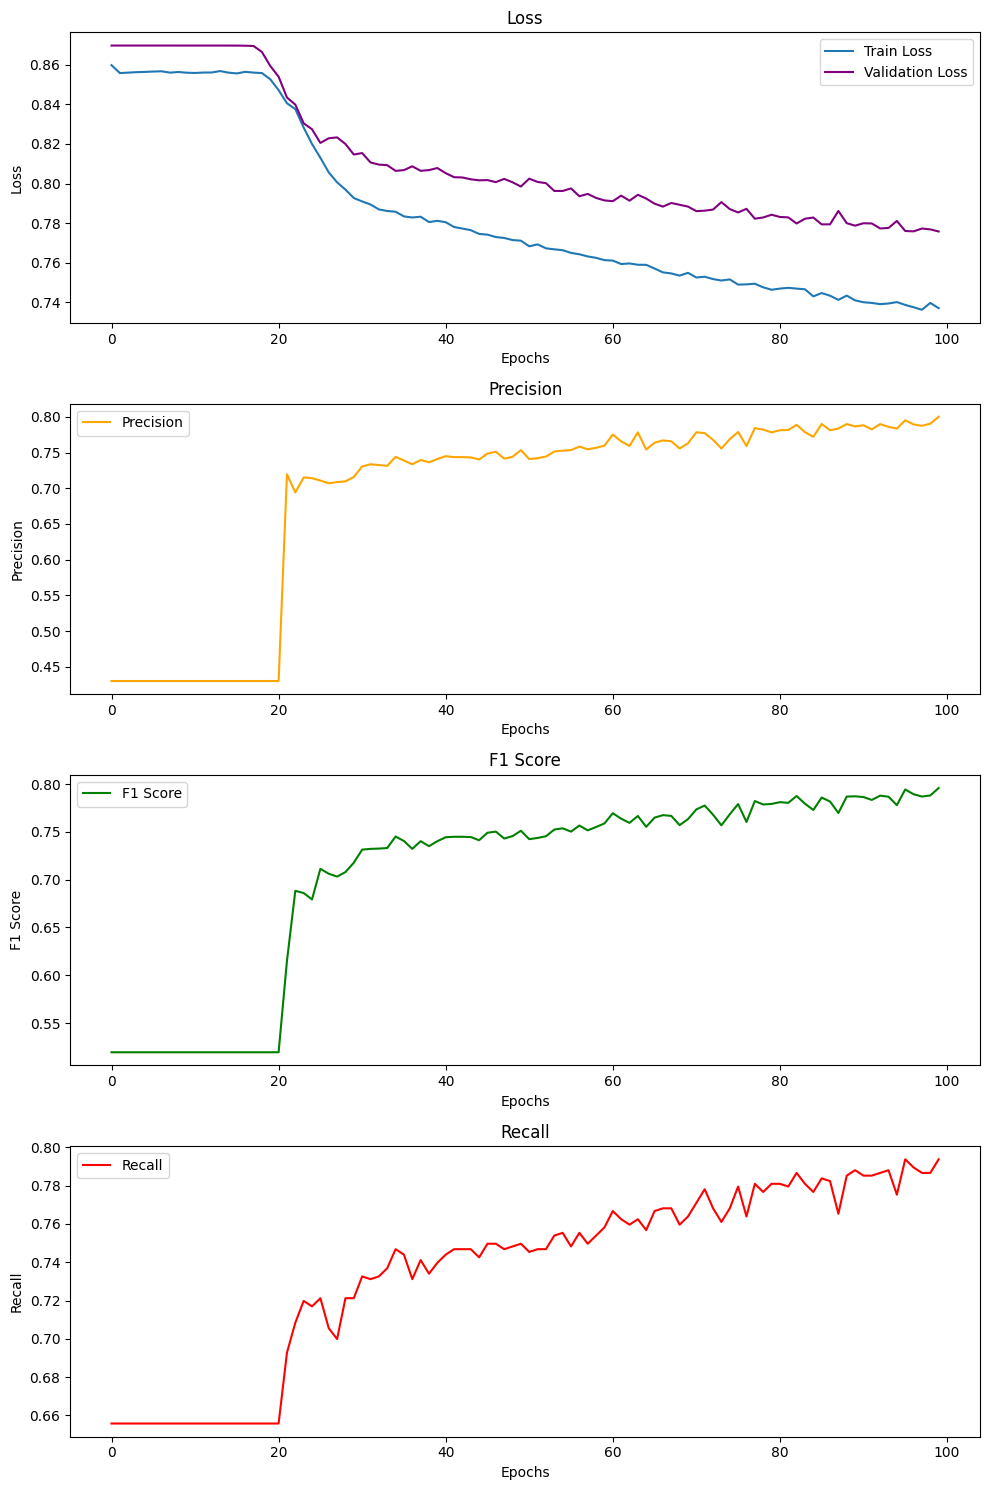

In [49]:
# plot the loss, precision, f1 and recall graphs
fig, axs = plt.subplots(4, 1, figsize=(10, 15))
axs[0].plot(loss_train_list, label='Train Loss')
axs[0].plot(loss_val_list, label='Validation Loss', color='purple')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[1].plot(precision_list, label='Precision', color='orange')
axs[1].set_title('Precision')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Precision')
axs[1].legend()
axs[2].plot(f1_list, label='F1 Score', color='green')
axs[2].set_title('F1 Score')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('F1 Score')
axs[2].legend()
axs[3].plot(recall_list, label='Recall', color='red')
axs[3].set_title('Recall')
axs[3].set_xlabel('Epochs')
axs[3].set_ylabel('Recall')
axs[3].legend()
plt.tight_layout()
plt.show()

In [ ]:
def cross_validate(model, dataset, k=5):
    """Realiza k-fold cross-validation en el conjunto de datos dado.

    Args:
        model (nn.Module): Modelo de PyTorch a evaluar.
        dataset (Dataset): Conjunto de datos a utilizar.
        k (int): Número de folds para la validación cruzada.
    Returns:
        dict: Diccionario con las métricas promedio de precisión, recall y F1-score.
    """
    
    fold_size = len(dataset) // k
    metrics = {'precision': [], 'recall': [], 'f1_score': [], 'val_loss': [], 'val_accuracy': []}
    metrics_fold = {}
    for fold in range(k):
        val_start = fold * fold_size
        val_end = val_start + fold_size if fold != k - 1 else len(dataset)

        val_subset = torch.utils.data.Subset(dataset, range(val_start, val_end))
        train_indices = list(range(0, val_start)) + list(range(val_end, len(dataset)))
        train_subset = torch.utils.data.Subset(dataset, train_indices)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

        # Re-inicializar el modelo para cada fold
        model_fold = ShallueModel2DSkip(global_size=2001, local_size=201, num_classes=n_classes, wavelet_levels=wavelet_levels).to(device)
        optimizer_fold = torch.optim.Adam(model_fold.parameters(), lr=learning_rate, weight_decay=l2_penalty)

        # Entrenar el modelo en el conjunto de entrenamiento del fold
        for epoch in range(60):  # número reducido de épocas para cada fold
            train_fn(model_fold, train_loader, optimizer_fold, loss_fn)

            # Evaluar el modelo en el conjunto de validación del fold
            val_loss, val_accuracy, f1, precision, recall = val_fn(model_fold, val_loader, loss_fn)
        
            metrics['precision'].append(precision)
            metrics['recall'].append(recall)
            metrics['f1_score'].append(f1)
            metrics['val_loss'].append(val_loss)
            metrics['val_accuracy'].append(val_accuracy)
            metrics_fold[fold] = {k: np.mean(v) for k, v in metrics.items()}

    return metrics_fold

train_xval_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])
xval_metrics = cross_validate(model, train_xval_dataset, k=5)
print("Cross-validation metrics:")
for fold, metrics in xval_metrics.items():
    print(f"Fold {fold}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


# plot: una gráfica por fold con las métricas principales
import matplotlib.pyplot as plt

for fold, m in xval_metrics.items():
    # métricas a mostrar en la primera gráfica (escala 0-1)
    score_names = ['precision', 'recall', 'f1_score', 'val_accuracy']
    scores = [m.get(name, np.nan) for name in score_names]

    # val_loss en una segunda gráfica (puede no estar en rango 0-1)
    val_loss = m.get('val_loss', np.nan)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})
    axs[0].bar(score_names, scores, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:purple'])
    axs[0].set_ylim(0, 1)
    axs[0].set_title(f'Fold {fold} — Scores')
    axs[0].set_ylabel('Valor')

    axs[1].bar(['val_loss'], [val_loss], color='tab:red')
    axs[1].set_title('Validation Loss')
    axs[1].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)

    plt.suptitle(f'Cross-validation Fold {fold}')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Entrenar modelo con todo el conjunto de entrenamiento + validación
model = ShallueModel2DSkip(global_size=2001, local_size=201, num_classes=n_classes, wavelet_levels=wavelet_levels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

for epoch in tqdm(range(num_epochs)):
    train_loss, train_accuracy = train_fn(model, DataLoader(train_xval_dataset, batch_size=batch_size, shuffle=True), optimizer, loss_fn)
    
print("Entrenamiento completo con conjunto de entrenamiento + validación.")



Binary classification → sigmoid output
Wavelet levels: [[3, 4, 5, 6], [1, 2, 3, 4]]
c_in: 4 (global), 4 (local)
Número de features concatenados: 66304


100%|██████████| 100/100 [07:08<00:00,  4.28s/it]


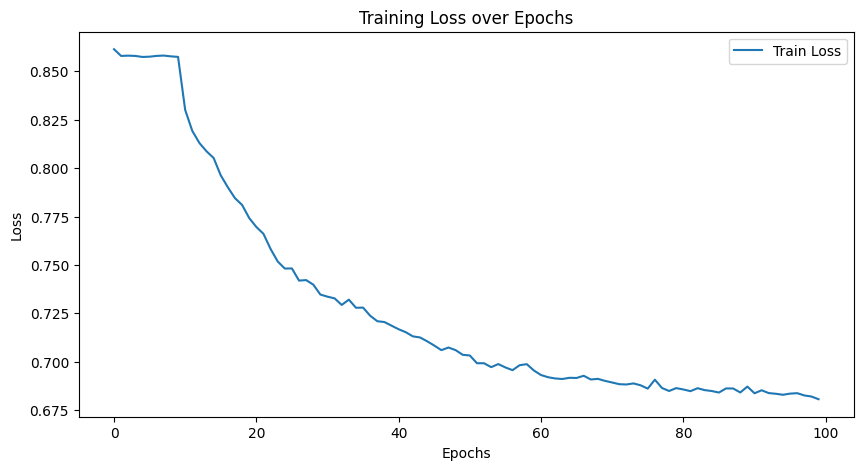

In [50]:
data_train_val = torch.utils.data.ConcatDataset([train_dataset, val_dataset])
loss_list = []
accuracy_list = []
model = Shallue2DSkip2Channels(global_size=global_size, local_size=local_size, num_classes=n_classes, wavelet_levels=wavelet_levels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)
schedule = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

for epoch in tqdm(range(num_epochs)):
    
    loss, accuracy = train_fn(model, DataLoader(data_train_val, batch_size=batch_size, shuffle=True), optimizer, loss_fn)
    schedule.step(loss)
    loss_list.append(loss)
    accuracy_list.append(accuracy)
    

plt.figure(figsize=(10, 5))
plt.plot(loss_list, label='Train Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Evaluar el modelo final en el conjunto de prueba


In [26]:
torch.save(model.state_dict(), 'models/model_B3_xval_skip.pth')

In [15]:
model = ShallueModel2DSkip(global_size=2001, local_size=201, num_classes=n_classes, wavelet_levels=wavelet_levels).to(device)
model.load_state_dict(torch.load('models/ShallueSkip_best.pth'))


Binary classification → sigmoid output
Wavelet levels: [1, 2, 3, 4]
c_in: 8
Número de features concatenados: 132608


<All keys matched successfully>

In [51]:
def predict(model, data_loader, loss_fn):
    predicted = []
    probs = []
    labels = []
    loss_test = []

    model.eval()

    with torch.no_grad():
        for data in data_loader:
            global_s, local_s, label = data
            # check if any tensor is empty
            if global_s.numel() == 0 or local_s.numel() == 0:
                predicted.append(np.full_like(label, -1))
                labels.append(np.full_like(label, -1))
                probs.append(np.full_like(label, -1))
                loss_test.append(np.nan)
                continue
            # check if any tensor has nan
            if torch.isnan(global_s).any() or torch.isnan(local_s).any():
                predicted.append(np.full_like(label, -1))
                labels.append(np.full_like(label, -1))
                probs.append(np.full_like(label, -1))
                continue
            
            global_s = global_s.to(device)#.unsqueeze(1).float()
            local_s = local_s.to(device)#.unsqueeze(1).float()
            label = label.to(device)

            
            output = model((global_s, local_s))
            if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
            # elimnar la dimensión extra de outputs
                output = output.squeeze(1)
                label = label.float()

            loss = loss_fn(output, label)
            loss_test.append(loss.item())
            
            if type(loss_fn) == nn.BCEWithLogitsLoss or type(loss_fn) == FocalLoss:
                predicted.append((output.cpu() > 0.5).float())
            else:
                _, predicted_label = torch.max(output.data, 1)
                predicted.append(predicted_label.cpu().numpy())
            
            labels.append(label.cpu().numpy())
            probs.append(output.cpu().numpy())
    predicted = np.concatenate(predicted)
    labels = np.concatenate(labels)
    probs = np.concatenate(probs)
    # loss_test = np.concatenate(loss_test)
    return predicted, labels, probs, loss_test

In [52]:
def plot_confusion_matrix(y_true, y_pred, classes, title = 'Confusion Matrix'):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(title)
    # plot stats
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    plt.text(2.7, 0.5, f'Accuracy: {accuracy:.4f}\nF1: {f1:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}', 
             horizontalalignment='center', verticalalignment='center', fontsize=12, color='black')
    plt.show()
    
# plot the ROC curve
def plot_roc_curve(y_true, y_pred, title='ROC Curve'):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()
    
def plot_loss(loss):
    plt.figure(figsize=(10, 5))
    plt.plot(loss)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

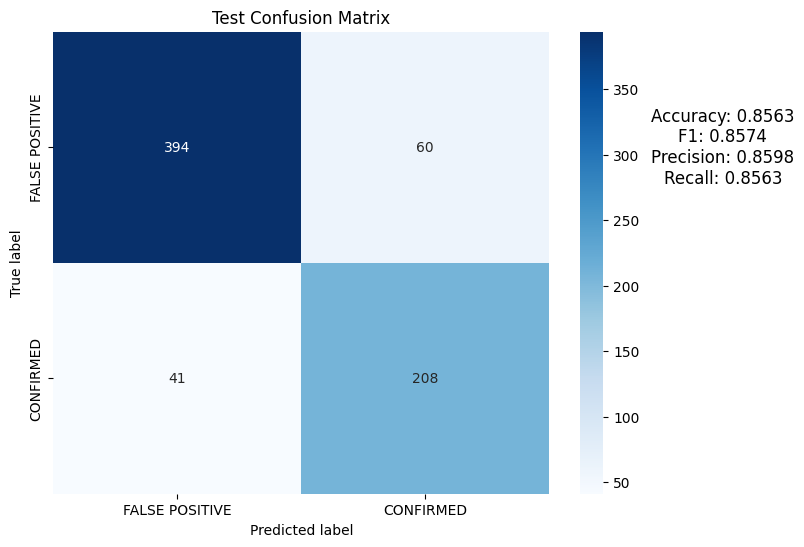

In [53]:
predicted, labels, probs, loss_serie  = predict(model, test_loader, loss_fn)
classes = ['FALSE POSITIVE', 'CONFIRMED']
plot_confusion_matrix(labels, predicted, classes, title='Test Confusion Matrix')
# plot_loss(loss_serie)
# plot_roc_curve(labels, predicted, title='Test ROC Curve')

## Probar el modelo con los datos de CANDIDATOS

In [71]:
global_odd = []
global_even = []
local_odd = []
local_even = []
wl_candidates = []

for lc in tqdm(candidates, desc='Processing light curves'):
    global_odd.append(lc.pliegue_impar_global._light_curve.flux.value)
    global_even.append(lc.pliegue_par_global._light_curve.flux.value)
    local_odd.append(lc.pliegue_impar_local._light_curve.flux.value)
    local_even.append(lc.pliegue_par_local._light_curve.flux.value)
    # Extraer los niveles de wavelet
    wl_candidates.append({
        'global_odd': lc.pliegue_impar_global._lc_w_collection,
        'global_even': lc.pliegue_par_global._lc_w_collection,
        'local_odd': lc.pliegue_impar_local._lc_w_collection,
        'local_even': lc.pliegue_par_local._lc_w_collection,
        'label': 2,  # etiqueta para candidatos
        'kepid': lc.kepler_id
    })

items_cand = []
items_cand = create_3D(wl_candidates, levels_global, levels_local, mode='a')
candidates_global = torch.tensor([item['global'] for item in items_cand], dtype=torch.float32).to(device)
candidates_local = torch.tensor([item['local'] for item in items_cand], dtype=torch.float32).to(device)
candidates_labels = torch.tensor([item['label'] for item in items_cand]).to(device)
candidates_dataset = torch.utils.data.TensorDataset(candidates_global, candidates_local, candidates_labels)

print("Tamaño del conjunto de candidatos:", len(candidates_dataset))

candidates_loader = DataLoader(candidates_dataset, batch_size=batch_size, shuffle=False)
print("Número de candidatos:", len(candidates_loader.dataset))

Processing light curves: 100%|██████████| 2272/2272 [00:00<00:00, 105621.17it/s]


Tamaño del conjunto de candidatos: 2272
Número de candidatos: 2272


In [72]:
predicted_candidates, _, probs, _ = predict(model, candidates_loader, loss_fn)
print(len(predicted_candidates))


2272


Exoplanetas confirmados: 974.0
Falso positivo: 1298.0


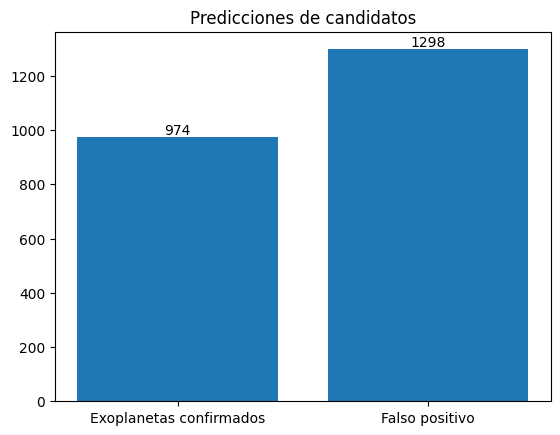

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


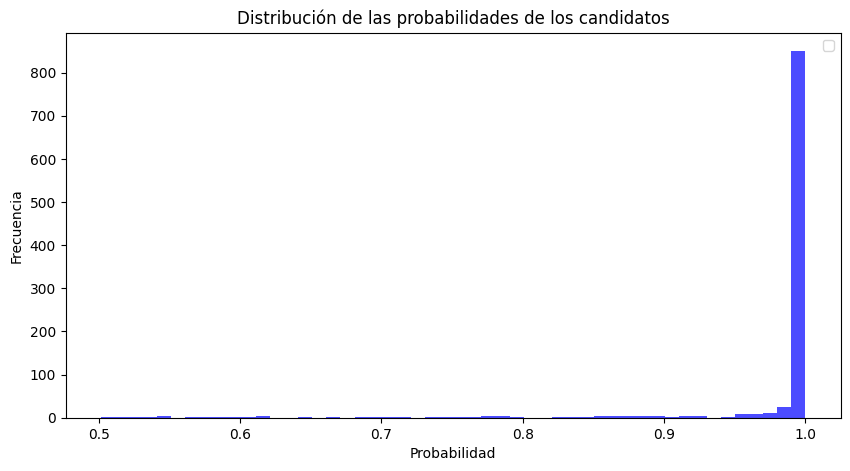

In [73]:
# contar los positivos y negativos
n_positive = sum(predicted_candidates)
n_negative = len(predicted_candidates) - n_positive
print("Exoplanetas confirmados:", n_positive)
print("Falso positivo:", n_negative)
plt.bar_label(plt.bar(['Exoplanetas confirmados', 'Falso positivo'], [n_positive, n_negative]))
plt.title('Predicciones de candidatos') 
plt.show()
# para el caso de confirmados evaluar la distribución de los valores de probabilidad
probs_confirmed = probs[predicted_candidates == 1]
plt.figure(figsize=(10, 5))
plt.hist(probs_confirmed, bins=50, color='blue', alpha=0.7)
plt.title('Distribución de las probabilidades de los candidatos')
plt.xlabel('Probabilidad')
plt.ylabel('Frecuencia')
# plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.legend()
plt.show()

In [76]:
# crear un DataFrame con los resultados y guardarlo en un archivo CSV
import pandas as pd
print("Guardando resultados en un DataFrame...")
print("Número de candidatos:", len(predicted_candidates))
print("candidates_dataset:", len(candidates_dataset))
df_results = pd.DataFrame({
    'id': [f'candidate_{i+1}' for i in range(len(predicted_candidates))],
    'kepler_name': [c.headers['Kepler_name'] for c in candidates],
    'kepid': [c.kepler_id for c in candidates],
    'predicted_2022': predicted_candidates,
    'class_2022': [c.headers['class_2022'] for c in candidates],
    'class_2025': [c.headers['class'] for c in candidates],
    'probability': probs,
})

df_results.to_csv('results/candidates_predictions_2022_vs_2025.csv', index=False)
print("Resultados guardados en 'results/candidates_predictions_2022_vs_2025.csv'.")

Guardando resultados en un DataFrame...
Número de candidatos: 2272
candidates_dataset: 2272
Resultados guardados en 'results/candidates_predictions_2022_vs_2025.csv'.


In [84]:
# analizar los candidatos que cambiaron de clase entre 2022 y 2025
changed_candidates = df_results[df_results['class_2022'] != df_results['class_2025']]
print("Número de candidatos que cambiaron de clase entre 2022 y 2025:", len(changed_candidates))
# calcular el error con respecto a las predicciones
changed_candidates['error'] = changed_candidates.apply(lambda row: 1 if (row['predicted_2022'] == 1 and row['class_2025'] == 'FALSE POSITIVE') or (row['predicted_2022'] == 0 and row['class_2025'] == 'CONFIRMED') else 0, axis=1)
print("Candidatos que cambiaron de clase entre 2022 y 2025:")
print(changed_candidates)
# calcular el porcentaje de error
error_rate = changed_candidates['error'].sum() / len(changed_candidates) * 100
print(f"Porcentaje de error en candidatos que cambiaron de clase: {error_rate:.2f}%")
changed_candidates.to_csv('results/changed_candidates_2022_vs_2025.csv', index=False)

Número de candidatos que cambiaron de clase entre 2022 y 2025: 373
Candidatos que cambiaron de clase entre 2022 y 2025:
                  id kepler_name     kepid  predicted_2022 class_2022  \
3        candidate_4   K01940.01  10005788             1.0  CANDIDATE   
12      candidate_13   K01574.01  10028792             1.0  CANDIDATE   
13      candidate_14   K01574.02  10028792             0.0  CANDIDATE   
17      candidate_18   K01608.01  10055126             1.0  CANDIDATE   
18      candidate_19   K01608.02  10055126             1.0  CANDIDATE   
...              ...         ...       ...             ...        ...   
2254  candidate_2255   K00593.01   9958962             0.0  CANDIDATE   
2255  candidate_2256   K00593.02   9958962             0.0  CANDIDATE   
2256  candidate_2257   K00593.03   9958962             0.0  CANDIDATE   
2266  candidate_2267   K02018.01   9973109             1.0  CANDIDATE   
2268  candidate_2269   K06214.01   9974142             0.0  CANDIDATE   

   

d:\Diego\Astrofisica\TFM\ExoPlanet-Detection\.venv\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


Índice del candidato confirmado: 14
Índice del falso positivo: 790


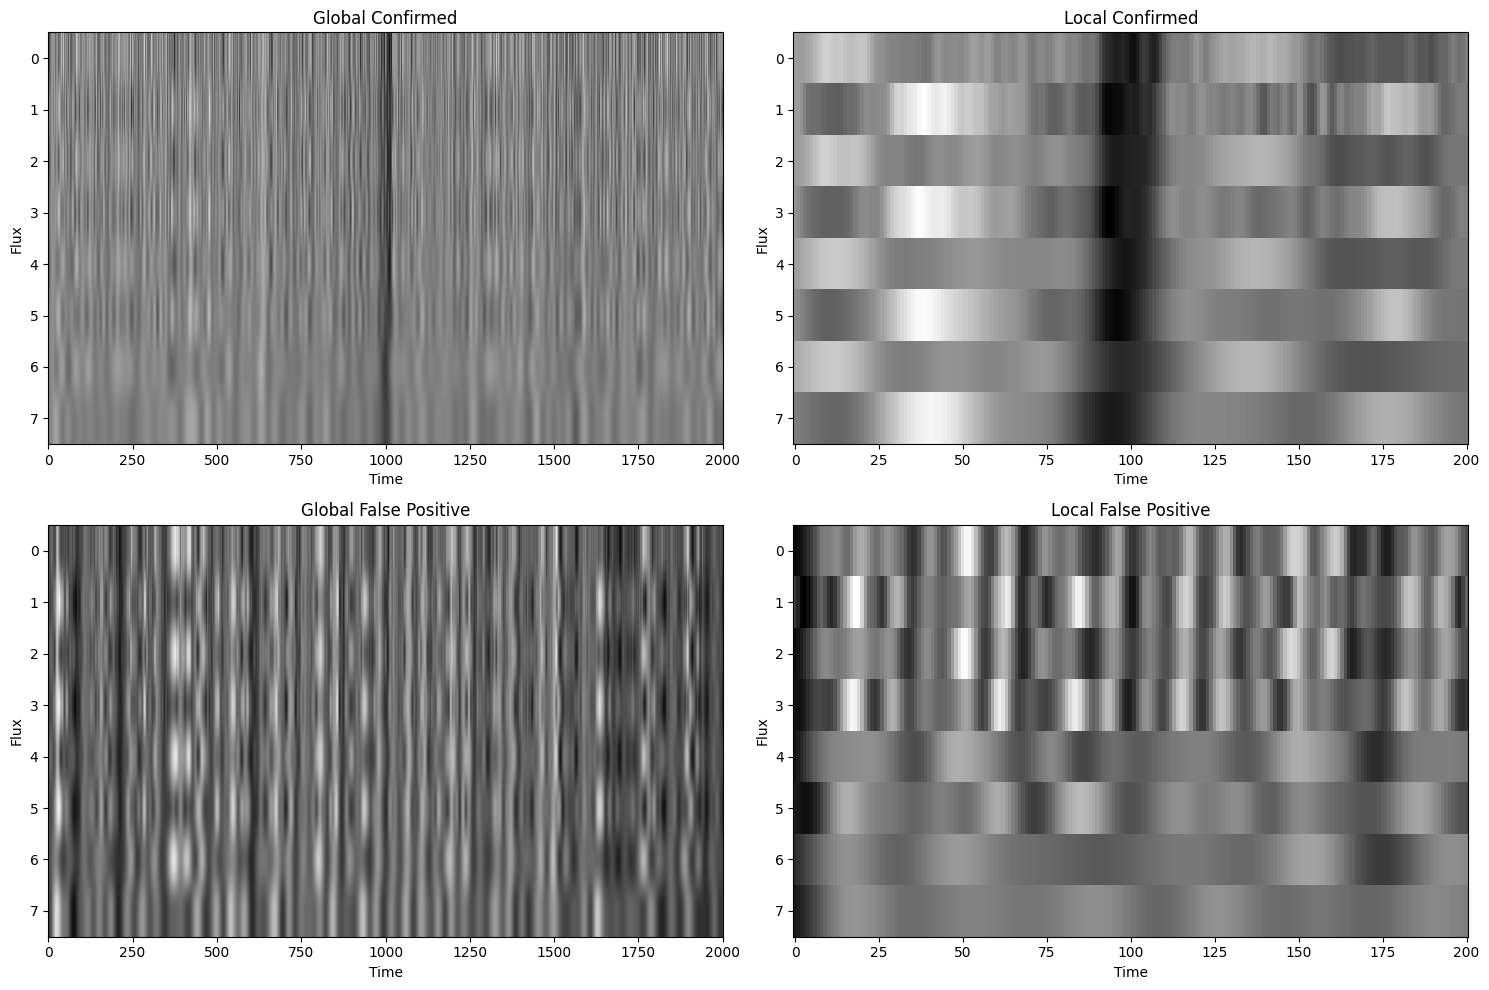

In [26]:
# comparar series de un condidato confirmado y uno falso positivo
# coger la posición de un candidato confirmado y uno falso positivo (1 y 0 respectivamente) en las probabilidades
confirmed_index = np.where(probs == 1)[0][0]
false_positive_index = np.where(probs == 0)[0][0]
print("Índice del candidato confirmado:", confirmed_index)
print("Índice del falso positivo:", false_positive_index)

confirmed_global = items_cand[confirmed_index]['global']
confirmed_local = items_cand[confirmed_index]['local']
false_positive_global = items_cand[false_positive_index]['global']
false_positive_local = items_cand[false_positive_index]['local']
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].imshow(confirmed_global, aspect='auto', cmap='gray')
ax[0, 0].set_title('Global Confirmed')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Flux')
ax[0, 1].imshow(confirmed_local, aspect='auto', cmap='gray')
ax[0, 1].set_title('Local Confirmed')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Flux')
ax[1, 0].imshow(false_positive_global, aspect='auto', cmap='gray')
ax[1, 0].set_title('Global False Positive')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Flux')
ax[1, 1].imshow(false_positive_local, aspect='auto', cmap='gray')
ax[1, 1].set_title('Local False Positive')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Flux')
plt.tight_layout()
plt.show()
